In [2]:
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
print(jax.local_devices()[0].device_kind)
from jax import numpy as np, random as jr, tree as jtu
import os

os.chdir("../amigo/src/amigo")


from zodiax.optimisation import sgd, adam

import amigo
import dorito


# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


/home/max/miniforge3/envs/nuke/lib/python3.13/site-packages/amigo/optical_models.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [3]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

data_path = os.path.join(morgana, "snert/max/data/JWST/PDS70/calslope/")
uncal_path = os.path.join(morgana, "snert/max/data/JWST/PDS70/uncal/")
amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, "outputs/PDS70/")

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    "F430M",
    "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

# Loading in data

In [4]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
# nsci = 1; ncal = 4
rolls = {}
sci_files = []
cal_files = []

for file in files:

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1

    if file[0].header["TARGPROP"] == "TD-PDS-70":
        file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?

    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

In [5]:
from astropy.time import Time

for file in files:
    h = file[0].header
    t = Time(h["EXPMID"], format="mjd")
    print(
        f'{h["TARGPROP"]} {h["FILTER"]}, Dither {h["PATT_NUM"]}/{h["NUMDTHPT"]}, Roll {h["ROLL_REF"]:.1f}deg, {h["XPOSURE"] / 60:.1f}min, {t.iso}, Groups {h["NGROUPS"]}, Ints {h["NINTS"]}'
    )

HD 228337 F480M, Dither 1/1, Roll 302.2deg, 15.2min, 2023-02-24 19:20:07.785, Groups 29, Ints 418
HD 228337 F430M, Dither 1/1, Roll 302.2deg, 12.7min, 2023-02-24 19:36:30.612, Groups 20, Ints 507
HD 228337 F380M, Dither 1/1, Roll 302.2deg, 7.7min, 2023-02-24 19:49:00.589, Groups 10, Ints 612
TD-PDS-70 F480M, Dither 1/1, Roll 301.7deg, 50.5min, 2023-02-24 21:05:08.000, Groups 96, Ints 418
TD-PDS-70 F430M, Dither 1/1, Roll 301.7deg, 40.4min, 2023-02-24 21:52:27.644, Groups 64, Ints 502
TD-PDS-70 F380M, Dither 1/1, Roll 301.7deg, 36.8min, 2023-02-24 22:33:15.992, Groups 49, Ints 597


In [6]:
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()

# cal_exposures = [ModelFit(file, depth_threshold=15e3) for file in cal_files]
# sci_exposures = [ModelFit(file, depth_threshold=15e3) for file in sci_files]
# exposures = cal_exposures + sci_exposures
# exposure = exposures[:1]  # for testing
# exp = exposures[0]  # for testing

exp = amigo.model_fits.ModelFit(file, use_cov=True)

model = amigo.core_models.AmigoModel(
    [exp],
    # exposures,
    optics=amigo.optical_models.AMIOptics(psf_upsample=1),
    detector=amigo.detector_models.LinearDetector(),
    ramp_model=amigo.ramp_models.NonLinearRamp(),
    read=amigo.read_models.ReadModel(),
    vis_model=None,
    state=load_dict(cache + "calibration.npy"),
)

In [ ]:
from scipy.ndimage import binary_dilation


def get_depth(exp, threshold=30_000):
    depth_cube = []
    for group in exp.ramp[1:]:
        group = np.where(exp.badpix, np.nan, group)
        sat_badpix = binary_dilation(group > threshold)
        depth_cube.append(sat_badpix)

    return (exp.ngroups - 1) - np.array(depth_cube, dtype=int).sum(0)


def fudge_cov_pp(cov, d, bajillion):
    cov = cov.at[d:, :].set(0.0)
    cov = cov.at[:, d:].set(0.0)
    cov = cov.at[d:, d:].set(bajillion * np.eye((cov.shape[0] - d)))
    return cov


def fudge_cov(cov, depth, bajillion=1e30):
    """Modifies a (48, 48, 80, 80) covariance array in-place,
    using per-pixel depths (80, 80)"""
    h, w = depth.shape
    final_cov = np.empty_like(cov)

    for i in range(h):
        for j in range(w):
            d = int(depth[i, j])
            this_cov = fudge_cov_pp(cov[..., i, j], d, bajillion)
            final_cov = final_cov.at[..., i, j].set(this_cov)

    return final_cov

In [22]:
fudged_cov = fudge_cov(exp.cov, get_depth(exp, threshold=15_000))

In [23]:
print(exp.cov.shape, fudged_cov.shape)

(48, 48, 80, 80) (48, 48, 80, 80)


In [47]:
# cov = exp.cov.reshape(-1, 48, 48)

counter = 0
for j in range(40, 51):
    for i in range(35, 46):

        fig, ax = plt.subplots(1, 3, figsize=(9, 2))

        ax[0].imshow(exp.slopes[-1])

        rect = mpl.patches.Rectangle(
            (j - 0.5, i - 0.5), 1, 1, linewidth=1, edgecolor="red", facecolor=None
        )
        ax[0].add_patch(rect)
        ax[0].set(title=f"Pixel {i}, {j}")
        ax[0].axis("off")

        this = exp.cov[..., i, j]
        c = ax[1].imshow(
            # this,
            this.at[np.eye(this.shape[-1], dtype=bool)].set(np.nan),
            seismic,
            norm=mpl.colors.CenteredNorm(),
            origin="upper",
        )
        fig.colorbar(c, ax=ax[1])
        ax[1].set(title="Covariance")

        this = fudged_cov[..., i, j]
        c = ax[2].imshow(
            # this,
            this.at[np.eye(this.shape[-1], dtype=bool)].set(np.nan),
            seismic,
            norm=mpl.colors.CenteredNorm(),
            origin="upper",
        )
        fig.colorbar(c, ax=ax[2])
        ax[2].set(title="Fudged Covariance")

        # plt.tight_layout()
        # plt.show()
        plt.savefig(
            amigo_cache + f"outputs/gifs/cov_gif/cov_{counter:04d}.png", dpi=150
        )
        plt.close()

        counter += 1

        # raise ValueError("Stop here")

In [48]:
import dorito

dorito.plotting.create_gif_from_dir(
    amigo_cache + "outputs/gifs/cov_gif/", "cov.gif", duration=100
)

In [36]:
from jax import scipy as jsp


# Normal slopes for the (40, 40) pixel
o_slope = exp(model)[..., 40, 40]
o_data = exp.slopes[..., 40, 40]
o_cov = exp.cov[..., 40, 40]


t_lls = []
f_lls = []
t_zs = []
f_zs = []

bajillions = np.logspace(0, 30)
for bajillion in bajillions:

    d = 30  # depth parameter

    # Truncated slopes
    t_model = o_slope[:d]
    t_data = o_data[:d]
    t_cov = o_cov[:d, :d]

    # Fudged slopes
    f_model = o_slope.copy()
    f_data = o_data.copy()
    f_cov = fudge_cov_pp(o_cov, d, bajillion)

    # o_lls.append(ll_fn(o_slope, o_data, o_cov))
    t_lls.append(amigo.stats.loglike(t_model, t_data, t_cov))
    t_zs.append(amigo.stats.mv_zscore(t_model, t_data, t_cov))
    f_lls.append(amigo.stats.loglike(f_model, f_data, f_cov))
    f_zs.append(amigo.stats.mv_zscore(f_model, f_data, f_cov))

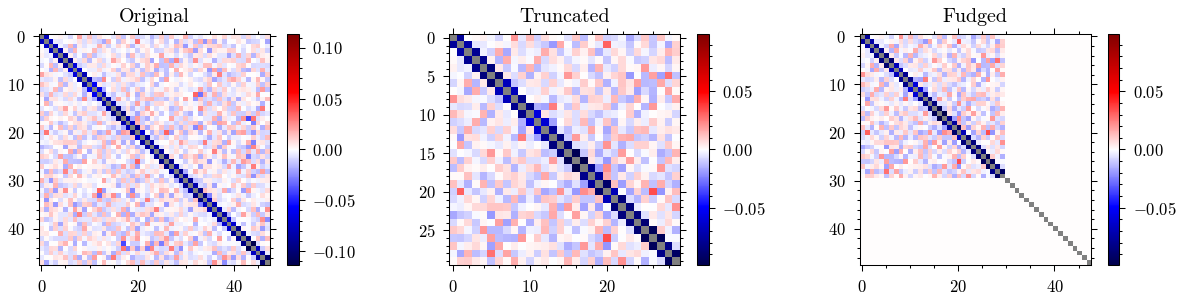

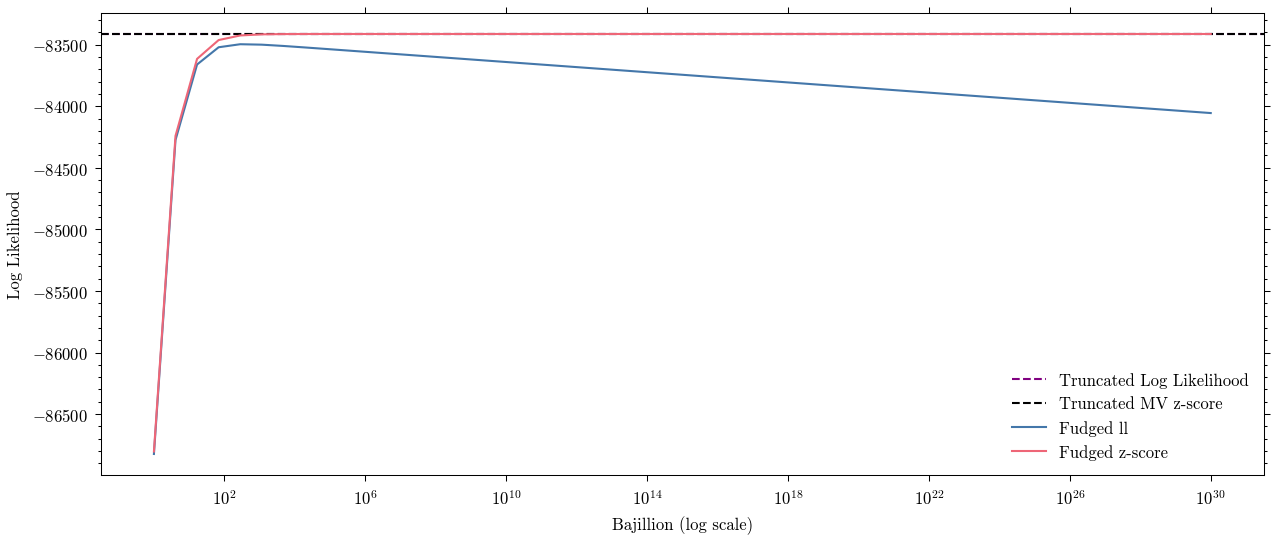

In [46]:
plt.figure(figsize=(10, 2))
plt.subplot(131)
plt.imshow(
    o_cov.at[np.eye(o_cov.shape[0], dtype=bool)].set(np.nan),
    seismic,
    origin="upper",
    norm=mpl.colors.CenteredNorm(),
)
plt.colorbar()
plt.title("Original")
plt.subplot(132)
plt.imshow(
    t_cov.at[np.eye(t_cov.shape[0], dtype=bool)].set(np.nan),
    seismic,
    origin="upper",
    norm=mpl.colors.CenteredNorm(),
)
plt.colorbar()
plt.title("Truncated")
plt.subplot(133)
plt.imshow(
    f_cov.at[np.eye(f_cov.shape[0], dtype=bool)].set(np.nan),
    seismic,
    origin="upper",
    norm=mpl.colors.CenteredNorm(),
)
plt.colorbar()
plt.title("Fudged")
plt.show()

plt.figure(figsize=(10, 4))
plt.axhline(t_lls[0], label="Truncated Log Likelihood", c="purple", linestyle="--")
plt.axhline(t_zs[0], label="Truncated MV z-score", c="black", linestyle="--")
plt.plot(bajillions, f_lls, label="Fudged ll")
plt.plot(bajillions, f_zs, label="Fudged z-score")
plt.xscale("log")
plt.xlabel("Bajillion (log scale)")
plt.ylabel("Log Likelihood")
plt.legend()
plt.show()

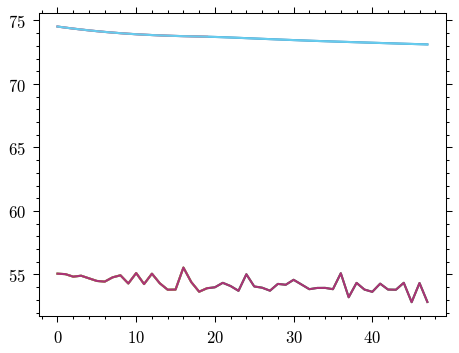

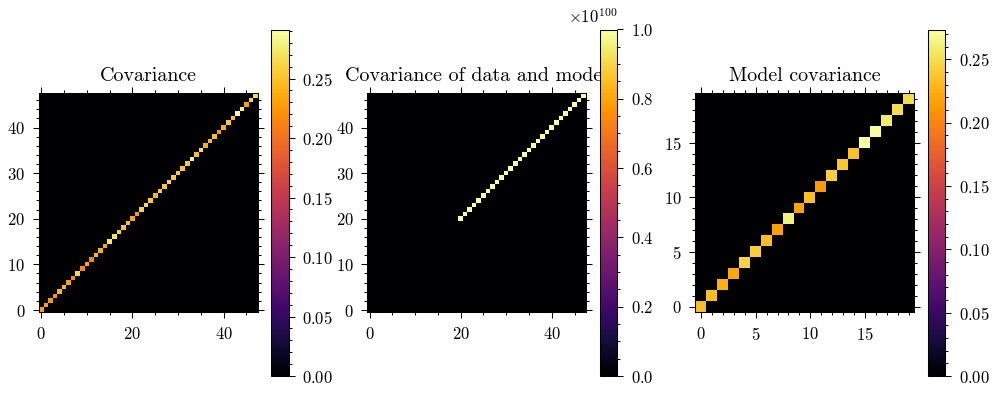

-189.9660446649139
-197.3175529305513


In [ ]:
# from scipy.ndimage import binary_dilation

# exp = exposures[0]
# print(exp.filter, exp.ngroups)

# base_badpix = exp.badpix

# threshold = 15_000

# vmax = np.nanmax(np.where(base_badpix, np.nan, exp.ramp[-1]))
# vmax2 = np.nanmax(np.where(base_badpix, np.nan, exp.slopes[0]))

# badpixcube = []

# for i, group in enumerate(exp.ramp[1:]):

#     frame = np.where(base_badpix, np.nan, group)

#     sat_badpix = binary_dilation(frame > threshold)
#     badpix = sat_badpix | base_badpix
#     slope = np.where(badpix, np.nan, exp.slopes[i])

#     plt.figure(figsize=(8, 2))

#     plt.subplot(131)
#     plt.title(f"Group {i}")
#     plt.imshow(frame, inferno, vmin=0, vmax=vmax)
#     plt.axis("off")
#     plt.colorbar()

#     plt.subplot(132)
#     plt.title("Saturation Bad Pixels")
#     plt.imshow(sat_badpix, cmap="gray", vmin=0, vmax=1)
#     plt.axis("off")
#     plt.colorbar()

#     plt.subplot(133)
#     plt.title("Combined Bad Pixels")
#     plt.imshow(slope, inferno, vmin=0, vmax=vmax2)
#     plt.axis("off")
#     plt.colorbar()

#     plt.tight_layout()
#     plt.show()
#     # plt.savefig(
#     #     f"files/badpix/badpix_{exp.filter}_{i:02d}.png",
#     #     dpi=300,
#     #     bbox_inches="tight",
#     # )
#     # plt.close()

#     badpixcube.append(badpix)

# badpixcube = np.array(badpixcube)

In [ ]:
# dorito.plotting.create_gif_from_dir("files/badpix/", "badpix.gif")

In [ ]:
from jax import vmap


def masked_loglike(slopes, data, cov, depth):
    return loglike(slopes[:depth], data[:depth], cov[:depth])


def loglike(exp, model, return_im=False):
    slopes = exp(model)

    # Get the model, data, and variances
    slope_vec = exp.to_vec(slopes)
    data_vec = exp.to_vec(exp.slopes)
    cov_vec = exp.to_vec(exp.cov)
    # depth_vec = exp.to_vec(exp.depth)

    # # Calculate per-pixel z-scores
    # z_vec = vmap(masked_loglike)(slope_vec, data_vec, cov_vec, depth_vec)

    # Calculate per-pixel z-scores
    z_vec = vmap(amigo.stats.loglike)(slope_vec, data_vec, cov_vec)

    # Return image or vector
    if return_im:
        # NOTE: Adds nans to the empty spots
        return exp.from_vec(z_vec)
    return z_vec

In [ ]:
loglike(exp, model)

Array([-25.36290655, -24.67058566, -28.71784139, ..., -18.76392655,
       -26.06619875, -27.96075416], dtype=float64)